# Setup

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer, KNNImputer

from implementations_Baseline import *


mod = ["mRNA", "DNAm" , "RPPA"]

#Loading data in merged_df and y_full
data_dir = "./../data/TCGA-BRCA/"
data = {}
for omic in mod : 
   with open(f"{data_dir}{omic}.pkl", "rb") as f:  # 'rb' = read binary
    data[omic] = pickle.load(f)

merged_df, y_full = merge_omics(data)



Merged data shape: (658, 130459)
              mRNA_ENSG00000000003.15  mRNA_ENSG00000000005.6  \
TCGA-3C-AALI                 9.255689                3.739151   
TCGA-3C-AALJ                      NaN                     NaN   
TCGA-3C-AALK                      NaN                     NaN   
TCGA-4H-AAAK                11.541035                4.903458   
TCGA-5L-AAT1                10.972233                4.163626   

              mRNA_ENSG00000000419.13  mRNA_ENSG00000000457.14  \
TCGA-3C-AALI                11.350330                11.771073   
TCGA-3C-AALJ                      NaN                      NaN   
TCGA-3C-AALK                      NaN                      NaN   
TCGA-4H-AAAK                10.708655                10.200338   
TCGA-5L-AAT1                10.978388                10.761782   

              mRNA_ENSG00000000460.17  mRNA_ENSG00000000938.13  \
TCGA-3C-AALI                 9.480035                 9.150829   
TCGA-3C-AALJ                      NaN          

In [97]:
# Sanity check
print(merged_df.index[:5])
print(y_full.index[:5])

Index(['TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK', 'TCGA-4H-AAAK',
       'TCGA-5L-AAT1'],
      dtype='object')
Index(['TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK', 'TCGA-4H-AAAK',
       'TCGA-5L-AAT1'],
      dtype='object')


In [98]:
#Fixed random state for reproducibility
RnSt=42

# Logistic regression

We evaluate the three variants of the baseline with cross_validation

In [105]:
#Number of folds for cross-validation
n_splits = 5

In [106]:
#PC components for each omic, by setting minimum variance explained to 0.7
PC = {
    'mRNA': 0.7,
    'DNAm': 0.7,
    'RPPA': 0.7
}

## By dropping the NaNs 

In [ ]:
#Pipeline for data preprocessing with sample dropping
#Missing data is dropped in crossval_log_reg, as it defaults to sample dropping when imputer_included is set to False.
pipelines_drop = {}
for omic, n_comp in PC.items():
    pipe_drop = make_pipeline(
        PCA(n_components=n_comp, random_state=RnSt),
        StandardScaler(),
        RenameFeatures(prefix=f"{omic}_PC")
    )
    pipelines_drop[omic] = pipe_drop

#Cross-validation 
accuracies_drop, macro_f1s_drop = crossval_log_reg(merged_df, y_full, preprocessings = pipelines_drop, imputer_included=False,  n_splits=n_splits, random_state=RnSt)

 


========== Fold 1 ==========
No imputation method added. Dropping samples with missing values.
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        13
        Her2       1.00      0.86      0.92         7
        LumA       0.90      0.90      0.90        48
        LumB       0.67      0.71      0.69        17

    accuracy                           0.87        85
   macro avg       0.89      0.86      0.88        85
weighted avg       0.87      0.87      0.87        85

Fold 1 Accuracy: 0.8706
Fold 1 macro F1: 0.8762

========== Fold 2 ==========
No imputation method added. Dropping samples with missing values.
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        12
        Her2       1.00      0.71      0.83         7
        LumA       0.84      0.91      0.88        47
        LumB       0.62      0.56      0.59        18

    accuracy                           0.83        84

## Median imputation

In [ ]:
#Pipeline for data preprocessing with median imputation
pipelines_median = {}
for omic, n_comp in PC.items():
    pipe_median = make_pipeline(
        SimpleImputer(strategy='median'),
        PCA(n_components=n_comp, random_state=RnSt),
        StandardScaler(),
        RenameFeatures(prefix=f"{omic}_PC")
    )
    pipelines_median[omic] = pipe_median

#Cross-validation
accuracies_med, macro_f1s_med = crossval_log_reg(merged_df, y_full, preprocessings = pipelines_median, imputer_included=True, n_splits=n_splits, random_state=RnSt)

 


========== Fold 1 ==========
              precision    recall  f1-score   support

       Basal       1.00      0.92      0.96        24
        Her2       0.75      0.90      0.82        10
        LumA       0.85      0.89      0.87        70
        LumB       0.68      0.61      0.64        28

    accuracy                           0.83       132
   macro avg       0.82      0.83      0.82       132
weighted avg       0.83      0.83      0.83       132

Fold 1 Accuracy: 0.8333
Fold 1 macro F1: 0.8208

========== Fold 2 ==========
              precision    recall  f1-score   support

       Basal       0.96      0.96      0.96        24
        Her2       0.86      0.60      0.71        10
        LumA       0.81      0.91      0.86        70
        LumB       0.68      0.54      0.60        28

    accuracy                           0.82       132
   macro avg       0.83      0.75      0.78       132
weighted avg       0.81      0.82      0.81       132

Fold 2 Accuracy: 0.818

## k-NN imputation

In [ ]:
#Pipeline for data preprocessing with KNN imputer
pipelines_knn = {}
for omic, n_comp in PC.items():
    pipe_knn = make_pipeline(
        KNNImputer(n_neighbors=6),
        StandardScaler(),
        PCA(n_components=n_comp, random_state=RnSt),
        RenameFeatures(prefix=f"{omic}_PC")
    )
    pipelines_knn[omic] = pipe_knn
#Cross-validation
accuracies_knn, macro_f1s_knn  = crossval_log_reg(merged_df, y_full, preprocessings = pipelines_knn,  n_splits=n_splits, random_state=RnSt)


========== Fold 1 ==========
              precision    recall  f1-score   support

       Basal       0.88      0.96      0.92        24
        Her2       0.62      0.80      0.70        10
        LumA       0.85      0.86      0.85        70
        LumB       0.73      0.57      0.64        28

    accuracy                           0.81       132
   macro avg       0.77      0.80      0.78       132
weighted avg       0.81      0.81      0.81       132

Fold 1 Accuracy: 0.8106
Fold 1 macro F1: 0.7767

========== Fold 2 ==========
              precision    recall  f1-score   support

       Basal       0.92      0.96      0.94        24
        Her2       0.73      0.80      0.76        10
        LumA       0.85      0.87      0.86        70
        LumB       0.67      0.57      0.62        28

    accuracy                           0.82       132
   macro avg       0.79      0.80      0.79       132
weighted avg       0.81      0.82      0.81       132

Fold 2 Accuracy: 0.818

# Comparison and visualisation

We visualise the results we obtained in the form of boxplots

In [ ]:
#Setting up dataframes for results visualization
df_f1_drop = pd.DataFrame({'fold': list(range(1, len(macro_f1s_drop)+1)), 'f1_macro': macro_f1s_drop})
df_f1_med = pd.DataFrame({'fold': list(range(1, len(macro_f1s_med)+1)), 'f1_macro': macro_f1s_med})
df_f1_knn = pd.DataFrame({'fold': list(range(1, len(macro_f1s_knn)+1)), 'f1_macro': macro_f1s_knn})
df_f1_drop['imputation'] = 'drop'
df_f1_med['imputation']  = 'median'
df_f1_knn['imputation']  = 'knn'

minimum = min(macro_f1s_drop + macro_f1s_med + macro_f1s_knn)

/var/folders/p2/lnfl0k0d5zd3lw9c13j04vzh0000gn/T/ipykernel_25233/691966830.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='imputation', y='f1_macro', data=df_combined, palette=['lightgray','C0','C1'])


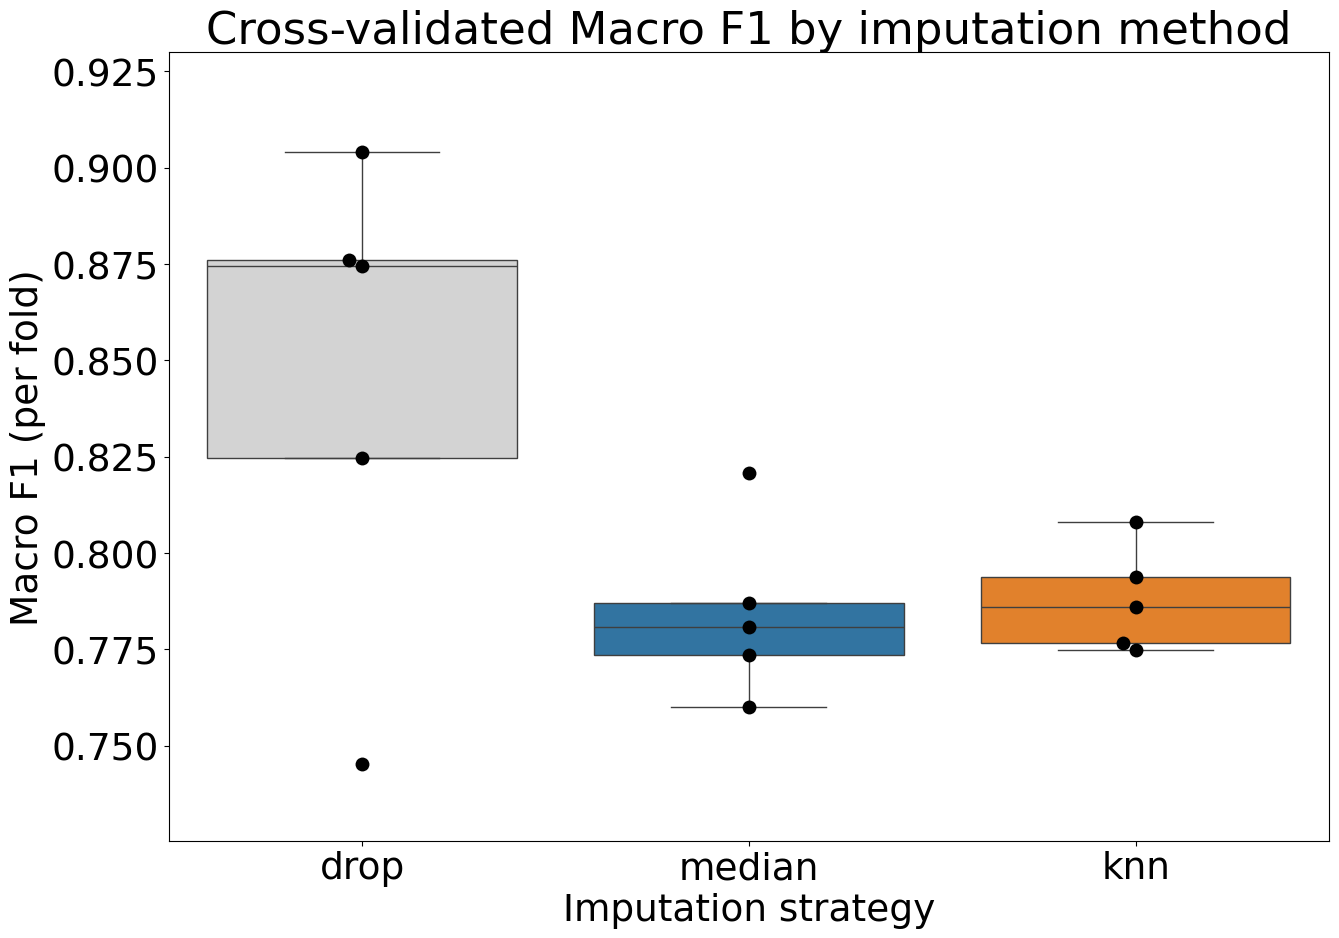

In [77]:
# Combine folds into a single DataFrame and plot all imputations in one plot, containing 3 boxplots
df_combined = pd.concat([df_f1_drop, df_f1_med, df_f1_knn], ignore_index=True)

plt.rcParams.update({'font.size': 27})
plt.figure(figsize=(14,10))
sns.boxplot(x='imputation', y='f1_macro', data=df_combined, palette=['lightgray','C0','C1'])
sns.swarmplot(x='imputation', y='f1_macro', data=df_combined, color='k', size=10)
plt.ylim(df_combined['f1_macro'].min()-0.02, 0.93)
plt.xlabel('Imputation strategy')
plt.ylabel('Macro F1 (per fold)')
plt.title('Cross-validated Macro F1 by imputation method')
plt.tight_layout()
plt.show()

# Hyperparameter tuning

From the above boxplots, we choose to optimise the first imputation strategy (dropping samples with missing values) due to its performance. It's also the least computationally costly one. 

We optimise macro F1 score while keeping the runtime inferior to the multi-omic models (MOFA, Pnet, IntegrAO). The best result is stored in best_results_baseline

In [ ]:
#Hyperparameter tuning over the cumulative variance explained by PCA
time_taken = []
best_performance = None
best_mean_f1 = 0

for i in np.arange (0.5,1,0.1):
    PC = {
        'mRNA': i,
        'DNAm': i,
        'RPPA': i
    }
    
    pipelines_drop = {}
    for omic, n_comp in PC.items():
        pipe_drop = make_pipeline(
        PCA(n_components=n_comp, random_state=RnSt),
        StandardScaler(),
        RenameFeatures(prefix=f"{omic}_PC")
        )   
        pipelines_drop[omic] = pipe_drop

    iter_start = time.perf_counter()
    
    _, macro_f1s, models, train_idxs = crossval_log_reg(merged_df, y_full, preprocessings = pipelines_drop, imputer_included=False, return_full_data=True,  n_splits=5, random_state=RnSt)

    if np.mean(macro_f1s) > best_mean_f1:
        best_mean_f1 = np.mean(macro_f1s)
        best_performance = {
        'macro_f1s': macro_f1s,
        'var_explained': i,
        'LR_models': models,
        'train_idxs': train_idxs
        }

    iter_end = time.perf_counter()
    iter_time = iter_end - iter_start 
    time_taken.append(iter_time/5)  # average running time per fold
    print(f"PC variance target: {i:.2f} — average iter time: {iter_time/5:.2f}s")



print("The best performance was obtained at (average F1,  variance explained) = ", best_performance['macro_f1s'], best_performance['var_explained'])
best_f1s_baseline = best_performance['macro_f1s']
best_results_baseline = pd.DataFrame({'fold': list(range(1, len(best_f1s_baseline)+1)), 'f1_macro': best_f1s_baseline})


========== Fold 1 ==========
No imputation method added. Dropping samples with missing values.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

       Basal       0.93      1.00      0.96        13
        Her2       1.00      0.57      0.73         7
        LumA       0.93      0.79      0.85        48
        LumB       0.58      0.88      0.70        17

    accuracy                           0.82        85
   macro avg       0.86      0.81      0.81        85
weighted avg       0.86      0.82      0.83        85

Fold 1 Accuracy: 0.8235
Fold 1 macro F1: 0.8105

========== Fold 2 ==========
No imputation method added. Dropping samples with missing values.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        12
        Her2       0.78      1.00      0.88         7
        LumA       0.90      0.77      0.83        47
        LumB       0.61      0.78      0.68        18

    accuracy                           0.82        84
   macro avg       0.82      0.89      0.85        84
weighted avg       0.84      0.82      0.83        84

Fold 2 Accuracy: 0.8214
Fold 2 macro F1: 0.8464

========== Fold 3 ==========
No imputation method added. Dropping samples with missing values.
              precision    recall  f1-score   support

       Basal       1.00      0.91      0.95        11
        Her2       0.60      0.50      0.55         6
        LumA       0.90      0.81      0.85        43
        LumB       0.45      0.64      0.53        14

    accuracy                           0.77        74
   macro avg       0.74      0.72      0.72        74
weighted avg       0.80      0.77      0.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

       Basal       0.92      0.92      0.92        12
        Her2       1.00      1.00      1.00         4
        LumA       0.90      0.98      0.94        45
        LumB       0.83      0.62      0.71        16

    accuracy                           0.90        77
   macro avg       0.91      0.88      0.89        77
weighted avg       0.89      0.90      0.89        77

Fold 4 Accuracy: 0.8961
Fold 4 macro F1: 0.8918

========== Fold 5 ==========
No imputation method added. Dropping samples with missing values.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        13
        Her2       0.80      1.00      0.89         4
        LumA       0.95      0.79      0.86        47
        LumB       0.58      0.82      0.68        17

    accuracy                           0.84        81
   macro avg       0.83      0.90      0.86        81
weighted avg       0.87      0.84      0.85        81

Fold 5 Accuracy: 0.8395
Fold 5 macro F1: 0.8581

Final results:

Mean Accuracy: 0.8302 ± 0.0404
Mean macro F1: 0.8254 ± 0.0586
Best macro F1 was obtained at fold 4 with value 0.8918
PC variance target: 0.50 — average iter time: 20.30s

========== Fold 1 ==========
No imputation method added. Dropping samples with missing values.
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        13
        Her2       1.00      0.57      0.73         7
        LumA       0.90      0.92      0.91        48
        LumB     

In [72]:
print(f"The optimised mean macro F1 is: {np.mean(best_f1s_baseline):.4f} ± {np.std(best_f1s_baseline):.4f}")


The optimised mean macro F1 is: 0.8450 ± 0.0560


# Interpretability

## Logistic regression coefficients

We explore the possibilities for interpreting data in the baseline, by studying logistic regression weights and  PCA loadings. We do this on the fold that gave us the best performance, whose information is stored inside the variable best_performance

Warning: the notation could be confusing here. best_performance is the data corresponding to the optimal threshold of explained variance for PCA. In particular it contains the data of the five folds of a cross-validation assessment.

From best_performance, we choose the fold with highest macro f1 (the 4th fold in this case) and study interpretability on this fold

In [120]:
logistic = best_performance['LR_models'][4-1]  # model from fold 4
logistic

LogisticRegression(class_weight='balanced', max_iter=5000, n_jobs=-1,
                   random_state=42, solver='saga')

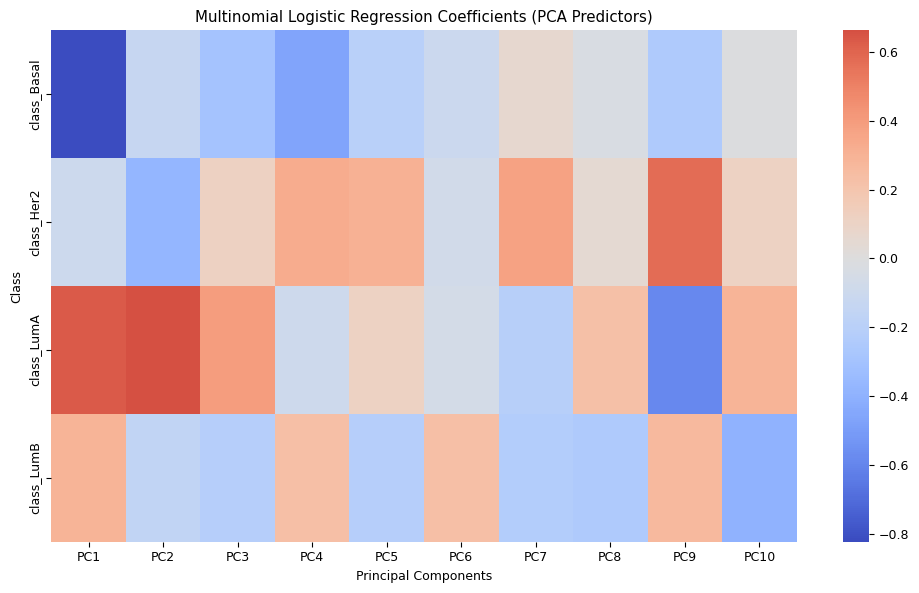

In [ ]:
coef_matrix = logistic.coef_ #Coefficient matrix of logistic regression
n_PC = 10 #Number of principal components to plot

#Heatmap of logistic regression coefficients, of shape (n_classes, n_PC), n_classes = 4
n_plot_cols = min(n_PC, coef_matrix.shape[1])
coef_df = pd.DataFrame(
    coef_matrix[:, :n_plot_cols],
    index=[f"class_{c}" for c in logistic.classes_],
    columns=[f"PC{i+1}" for i in range(n_plot_cols)],
)


plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=False, cmap="coolwarm", center=0)
plt.title("Multinomial Logistic Regression Coefficients (PCA Predictors)")
plt.xlabel("Principal Components")
plt.ylabel("Class")
plt.tight_layout()
plt.show()


## PCA loadings

In [168]:
#Setting up data from fold 4 of the best performing model (70% variance explained)

fold_train_idx = best_performance['train_idxs'][4-1]  # training indices from fold 4
fold_train_set = merged_df.iloc[fold_train_idx]
fold_data = {}

for omic in mod:
    fold_data[omic] = get_omic_split(fold_train_set, omic)
    fold_data[omic] = fold_data[omic].dropna()
    fold_data[omic].columns = fold_data[omic].columns.str.replace(f"{omic}_", "", regex=False)

var_expl = 0.7



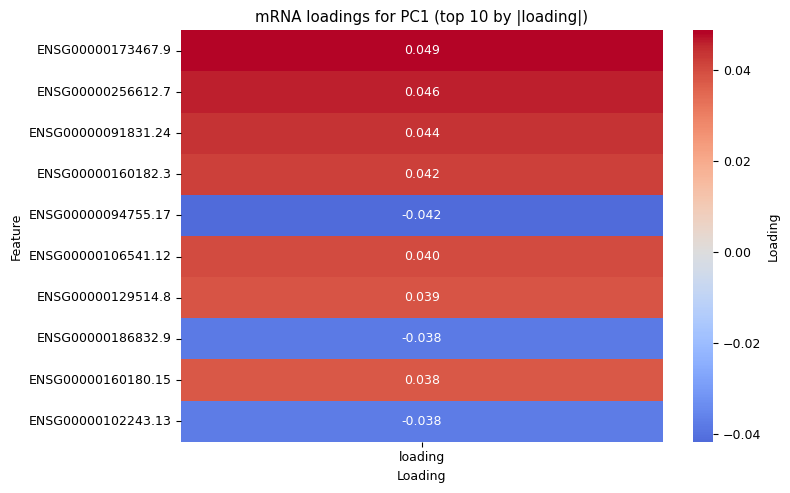

Top 10 mRNA features by absolute loading on PC1:
                     loading
feature                     
ENSG00000173467.9   0.048752
ENSG00000256612.7   0.045935
ENSG00000091831.24  0.043820
ENSG00000160182.3   0.041903
ENSG00000094755.17 -0.041676
ENSG00000106541.12  0.040180
ENSG00000129514.8   0.038667
ENSG00000186832.9  -0.037868
ENSG00000160180.15  0.037800
ENSG00000102243.13 -0.037602


In [169]:
loadings_heatmap(0.7, fold_data, data, 'mRNA', n = 1, top_k_heat=10)

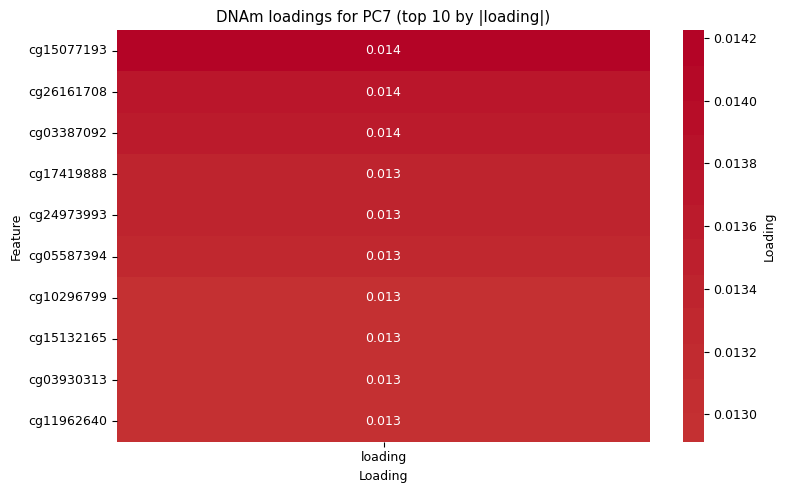

Top 10 DNAm features by absolute loading on PC7:
             loading
feature             
cg15077193  0.014224
cg26161708  0.013754
cg03387092  0.013591
cg17419888  0.013434
cg24973993  0.013428
cg05587394  0.013324
cg10296799  0.012978
cg15132165  0.012936
cg03930313  0.012932
cg11962640  0.012913


In [170]:
loadings_heatmap(0.7, fold_data, data, 'DNAm', n = 7, top_k_heat=10)

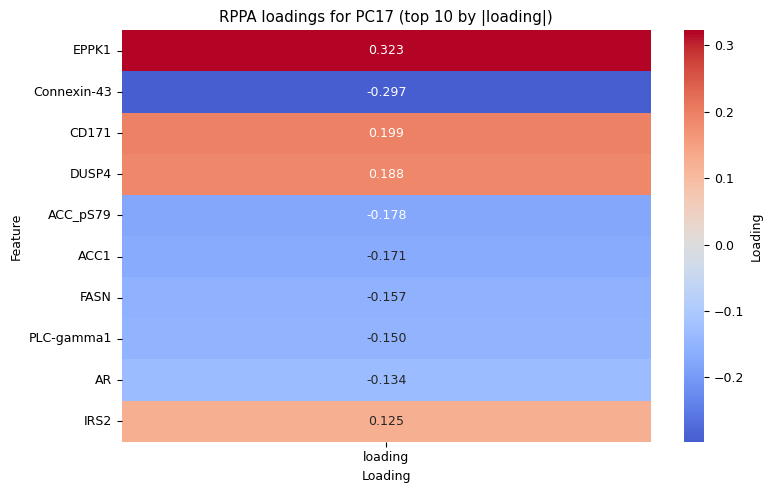

Top 10 RPPA features by absolute loading on PC17:
              loading
feature              
EPPK1        0.322701
Connexin-43 -0.297130
CD171        0.199073
DUSP4        0.187799
ACC_pS79    -0.177810
ACC1        -0.170595
FASN        -0.157242
PLC-gamma1  -0.149830
AR          -0.134137
IRS2         0.124924


In [171]:
loadings_heatmap(0.7, fold_data, data, 'RPPA', n = 17, top_k_heat=10)